# 05. Stress Tests under Imperfect Data and Supervision

## Goal

This notebook evaluates the selected housing-price model beyond standard predictive performance.

The central question is not only whether the model performs well on a clean benchmark, but whether it remains stable under:

- imperfect input data,
- subgroup heterogeneity,
- and imperfect supervision.

This stage is designed to connect the project to a broader trustworthy-ML perspective: a useful model should not collapse when the learning conditions become less ideal.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model import get_models
from stress_utils import (
    make_train_valid_split,
    fit_and_eval,
    add_numeric_noise,
    drop_feature_group,
    make_price_groups,
    subgroup_evaluation,
    corrupt_targets,
    compare_metric_dicts,
    collect_stress_results
)

## Input Data and Base Model

I use the processed training matrix generated in the previous stage.

The main model here is `GradientBoostingRegressor`, chosen because it performed best among the currently available nonlinear models in the model-comparison stage.

In [2]:
train_processed = pd.read_csv("../data/processed/train_processed.csv")

X = train_processed.drop("SalePrice_log", axis=1).copy()
y = train_processed["SalePrice_log"].copy()

# keep dtype fully numeric for consistency
X = X.astype(float)

X_train, X_valid, y_train, y_valid = make_train_valid_split(
    X, y, test_size=0.2, random_state=42
)

models = get_models(random_state=42)
gb_model = models["GradientBoosting"]

base_model, base_pred, base_metrics = fit_and_eval(
    gb_model, X_train, y_train, X_valid, y_valid
)

print("Base metrics:", base_metrics)

Base metrics: {'rmse': np.float64(0.11058757246234327), 'mae': 0.07401569988466851, 'r2': 0.9189852923892855}


## Why Stress Tests?

A model may perform well under standard evaluation and still fail when the input conditions become less ideal.

In this notebook, I treat robustness as a practical and analytical question:

- Which imperfections damage the model the most?
- Does the model fail gradually or abruptly?
- Are the learned patterns stable across different stress conditions?

## Test 1. Subgroup Robustness

First, I examine whether performance is evenly distributed across different price segments.

A model can appear strong on average while performing poorly on specific subgroups, which is an important failure mode in practical deployment.

In [3]:
price_groups = make_price_groups(y_valid, q=3)

subgroup_df = subgroup_evaluation(
    base_model,
    X_valid,
    y_valid,
    groups=price_groups,
    group_name="price_group"
)

subgroup_df

,price_group,count,rmse,mae,r2
0,high,97,0.080863,0.062673,0.862355
1,mid,96,0.087134,0.065793,0.132682
2,low,98,0.149683,0.093298,0.621827


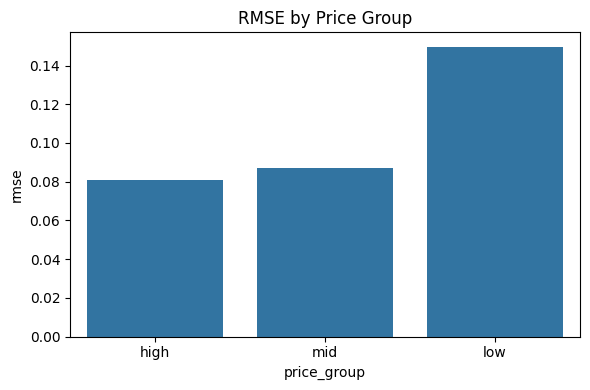

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(data=subgroup_df, x="price_group", y="rmse")
plt.title("RMSE by Price Group")
plt.tight_layout()
plt.show()

### Interpretation Angel

The subgroup analysis shows that model performance is not uniform across the housing market.

Prediction error is lowest for the high-price group, slightly higher for the mid-price group, and clearly highest for the low-price group. This suggests that the model fits expensive houses more reliably than cheaper ones.

A plausible explanation is that lower-priced homes may be more heterogeneous, noisier, or influenced by idiosyncratic factors that are less fully captured by the current feature set. This result is important because it shows that strong average performance can still hide subgroup-specific weakness.

## Test 2. Robustness to Feature Corruption

Next, I simulate mild measurement noise in selected numerical variables.

This reflects a realistic scenario in which property attributes are imperfectly recorded or preprocessed.

In [5]:
noise_cols = [
    c for c in ["GrLivArea", "TotalSF", "LotArea", "HouseAge", "TotalBath"]
    if c in X_valid.columns
]

X_valid_noise_3 = add_numeric_noise(X_valid, noise_cols, noise_scale=0.03, random_state=42)
noise3_pred = base_model.predict(X_valid_noise_3)
from stress_utils import evaluate_regression
noise3_metrics = evaluate_regression(y_valid, noise3_pred)

noise3_compare = compare_metric_dicts(base_metrics, noise3_metrics, "feature_noise_3pct")
noise3_compare

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,feature_noise_3pct,0.110588,0.110605,0.000017,0.074016,0.074062,0.000046,0.918985,0.91896,-0.000026


In [6]:
X_valid_noise_5 = add_numeric_noise(X_valid, noise_cols, noise_scale=0.05, random_state=42)
noise5_pred = base_model.predict(X_valid_noise_5)
noise5_metrics = evaluate_regression(y_valid, noise5_pred)

noise5_compare = compare_metric_dicts(base_metrics, noise5_metrics, "feature_noise_5pct")
noise5_compare

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,feature_noise_5pct,0.110588,0.1106,0.000012,0.074016,0.074216,0.0002,0.918985,0.918968,-0.000018


### Interpretation Angel

The model shows almost no degradation under 3% and 5% numerical perturbations in selected features.

This suggests that the fitted Gradient Boosting model is locally stable under mild measurement noise in major housing variables. In other words, small recording errors in size-related inputs do not materially change predictive performance.

At the same time, the extremely small difference between the 3% and 5% settings should not be overinterpreted. It is better read as evidence of strong short-range stability rather than as a precise monotonic effect.

## Test 3. Missing-Feature Scenario

I now simulate incomplete inputs by dropping selected feature groups.

This approximates a practical setting in which some variables are unavailable, unreliable, or too costly to collect.

In [7]:
garage_keywords = ["Garage"]
X_train_drop_garage = drop_feature_group(X_train, garage_keywords)
X_valid_drop_garage = drop_feature_group(X_valid, garage_keywords)

garage_model, garage_pred, garage_metrics = fit_and_eval(
    gb_model, X_train_drop_garage, y_train, X_valid_drop_garage, y_valid
)

garage_compare = compare_metric_dicts(base_metrics, garage_metrics, "drop_garage_features")
garage_compare

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,drop_garage_features,0.110588,0.113195,0.002608,0.074016,0.077203,0.003187,0.918985,0.91512,-0.003865


In [8]:
bsmt_keywords = ["Bsmt"]
X_train_drop_bsmt = drop_feature_group(X_train, bsmt_keywords)
X_valid_drop_bsmt = drop_feature_group(X_valid, bsmt_keywords)

bsmt_model, bsmt_pred, bsmt_metrics = fit_and_eval(
    gb_model, X_train_drop_bsmt, y_train, X_valid_drop_bsmt, y_valid
)

bsmt_compare = compare_metric_dicts(base_metrics, bsmt_metrics, "drop_basement_features")
bsmt_compare

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,drop_basement_features,0.110588,0.111199,0.000612,0.074016,0.074399,0.000383,0.918985,0.918086,-0.000899


### Interpretation Angle

Dropping garage-related features leads to the largest increase in RMSE among all stress tests, while dropping basement-related features produces a smaller but still noticeable degradation.

This indicates that the model depends meaningfully on garage information and, to a lesser extent, basement information. The implication is not that the model is fragile overall, but that some feature groups carry substantially more predictive value than others.

From a practical perspective, this means that missing garage information would be more damaging than missing basement information in this pipeline.

## Test 4. Imperfect Supervision via Target Corruption

Finally, I simulate imperfect supervision by corrupting the training target.

This is not a standard noisy-label classification benchmark, but it serves as a regression-style analogue: the supervision signal is made less reliable, and I observe how much performance degrades as a result.

In [9]:
y_train_corrupt_gaussian = corrupt_targets(
    y_train, mode="gaussian", scale=0.03, random_state=42
)

corrupt_model_1, corrupt_pred_1, corrupt_metrics_1 = fit_and_eval(
    gb_model, X_train, y_train_corrupt_gaussian, X_valid, y_valid
)

corrupt_compare_1 = compare_metric_dicts(base_metrics, corrupt_metrics_1, "target_corruption_gaussian_3pct")
corrupt_compare_1

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,target_corruption_gaussian_3pct,0.110588,0.110733,0.000146,0.074016,0.073869,-0.000146,0.918985,0.918772,-0.000213


In [10]:
y_train_corrupt_subset = corrupt_targets(
    y_train, mode="subset", scale=0.05, frac=0.15, random_state=42
)

corrupt_model_2, corrupt_pred_2, corrupt_metrics_2 = fit_and_eval(
    gb_model, X_train, y_train_corrupt_subset, X_valid, y_valid
)

corrupt_compare_2 = compare_metric_dicts(base_metrics, corrupt_metrics_2, "target_corruption_subset_15pct")
corrupt_compare_2

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,target_corruption_subset_15pct,0.110588,0.110614,0.000027,0.074016,0.074084,0.000068,0.918985,0.918946,-0.000039


### Interpretation angle

Under the mild target-corruption settings tested here, the model remains relatively stable.

Both Gaussian corruption and subset corruption produce only very small changes in RMSE, suggesting that the model is not highly sensitive to weak perturbations in the supervision signal.

This should be interpreted cautiously: the test only covers mild corruption settings, not severe label degradation. Still, it provides some evidence that the current pipeline is reasonably tolerant of small imperfections in the target values.

## Combined Stress-Test Summary

In [11]:
stress_summary = collect_stress_results([
    noise3_compare,
    noise5_compare,
    garage_compare,
    bsmt_compare,
    corrupt_compare_1,
    corrupt_compare_2
])

stress_summary

,test,base_rmse,stressed_rmse,delta_rmse,base_mae,stressed_mae,delta_mae,base_r2,stressed_r2,delta_r2
0,feature_noise_3pct,0.110588,0.110605,0.000017,0.074016,0.074062,0.000046,0.918985,0.918960,-0.000026
1,feature_noise_5pct,0.110588,0.110600,0.000012,0.074016,0.074216,0.000200,0.918985,0.918968,-0.000018
2,drop_garage_features,0.110588,0.113195,0.002608,0.074016,0.077203,0.003187,0.918985,0.915120,-0.003865
3,drop_basement_features,0.110588,0.111199,0.000612,0.074016,0.074399,0.000383,0.918985,0.918086,-0.000899
4,target_corruption_gaussian_3pct,0.110588,0.110733,0.000146,0.074016,0.073869,-0.000146,0.918985,0.918772,-0.000213
5,target_corruption_subset_15pct,0.110588,0.110614,0.000027,0.074016,0.074084,0.000068,0.918985,0.918946,-0.000039


In [12]:
results_df = stress_summary
results_df.to_csv("../results/tables/stress_summary.csv", index=False)

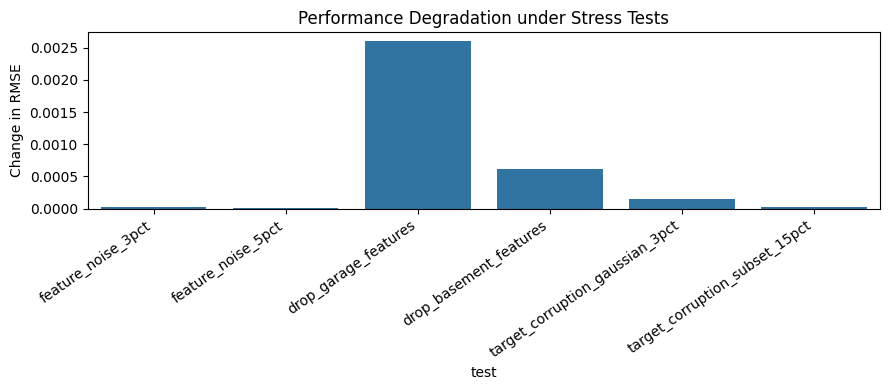

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=stress_summary, x="test", y="delta_rmse")
plt.xticks(rotation=35, ha="right")
plt.title("Performance Degradation under Stress Tests")
plt.ylabel("Change in RMSE")
plt.tight_layout()
plt.savefig("../results/figures/rmse_by_price_group.png", dpi=300, bbox_inches="tight")
plt.show()

## Overall Interpretation

Taken together, the stress tests suggest a nuanced picture of robustness.

On the positive side, the model is highly stable under mild numerical feature perturbation and mild target corruption. This indicates that the learned prediction function is not overly fragile under small imperfections in either inputs or supervision.

However, the stress tests also reveal two meaningful weaknesses:

1. performance is substantially worse in the low-price subgroup, and  
2. the model relies heavily on garage-related features.

Therefore, the main conclusion is not simply that the model is "robust" in a general sense, but that its robustness is conditional: it is stable under small perturbations, yet still sensitive to subgroup heterogeneity and the removal of certain highly informative feature groups.